# Multi-Stufen-Korpusanalyse: Rohdaten, Filterung & Normalisierung
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte/Einfache Sprache (LS)

Dieses Notebook bietet eine ganzheitliche quantitative und qualitative Untersuchung der **drei zentralen Datenstufen** unseres Übersetzungskorpus:

1. **Stufe 1 – Rohdaten (`2_raw_scraped`)**: Direkt aus den Scrapern extrahierte Artikelpaare. Enthalten noch Web-Floskeln (*„Mehr Informationen...“*, *„Klicken Sie hier“*), Prüfstellen-/Übersetzer-Signaturen, Mediopunkte (`·`, `∙`), irrelevante Teaser-Fragmente und redundante URL-Klone.
2. **Stufe 2 – Gefiltert (`3_filtered_similarity`)**: Nach semantischer Ähnlichkeit (Jina Embeddings $0.60 \le \text{sim} \le 0.98$), Mindest-Tokenlänge und Lorem-Ipsum-Ausschluss gefiltert (`filter_similarity.py`).
3. **Stufe 3 – Normalisiert & Bereinigt (`4_normalized_clean`)**: Vollständig dedupliziert, Mediopunkte bereinigt, quellenspezifisches und universelles Web-Boilerplate eliminiert sowie nach Längenverhältnis ($0.20 \le LS/AS \le 4.00, \ge 30$ Wörter) gefiltert (`normalize_clean.py`).

---
### Ziel dieser Auswertung:
- **Transparenz des Funnels**: Quantifizierung von Beibehaltungsraten, Klon-Deduplikation und Filterverlusten.
- **Volumen-Metriken**: Entwicklung von Text-, Wort- und LLM-Tokenzahlen (`tiktoken` cl100k_base) über die Stufen.
- **Längenverhältnisse**: Bereinigung extremer Ausreißer im $LS/AS$-Verhältnis.
- **Boilerplate-Eliminierung**: Detaillierte Vorher-Nachher-Prävalenz nach 5 Bias-Kategorien.
- **Qualitative Fallstudien**: Konkrete Text-Deltas vor und nach der Normalisierung.

In [1]:
import os
import sys
import glob
import json
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken
from tqdm.auto import tqdm
from IPython.display import display

# Arbeitsverzeichnis auf Projekt-Root setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

enc = tiktoken.get_encoding("cl100k_base")

def count_tokens(text: str) -> int:
    return len(enc.encode(text)) if text else 0

def count_sentences(text: str) -> int:
    if not text:
        return 0
    sentences = re.split(r'[.!?](?:\s+|$)|(?:\n\s*\n)', text)
    return len([s for s in sentences if s.strip()])

def tokenize_words(text: str) -> list:
    return re.findall(r'[\w∙·-]+', text.lower())

# Plotting-Design
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["font.sans-serif"] = "DejaVu Sans"


Aktuelles Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


## 1. Definition der Boilerplate- & Bias-Kategorien

Wir erfassen Web-Artefakte und Floskeln in 5 semantisch distinkten Hauptkategorien sowie Mediopunkte:
1. **Navigationsfloskeln & Link-Verweise**: *„Mehr Informationen finden Sie hier“*, *„Klicken Sie auf...“*, *„Hier erfahren Sie mehr“*.
2. **Frageketten & interaktive Tools**: *„Wo finde ich weitere Infos?“*, *„Sie möchten mehr wissen?“*, *„Unser Tool durchsucht...“*.
3. **Disclaimer & Link-Warnungen**: *„Dieser Link führt aus unserem Einfache-Sprache-Angebot heraus“*, *„In diesem Text finden Sie nur allgemeine Infos“*.
4. **Prüfstellen-, Übersetzer- & Logo-Credits**: *„Forschungsstelle Leichte Sprache“*, *„Universität Hildesheim“*, *„Stefan Albers“*, *„Inclusion Europe“*, *„Büro für Leichte Sprache“*.
5. **Regionale & Bild-Artefakte**: *„Icon für die Mobilversion“*, *„Von der Straße aus fotografiert“*, *„Das Team vom Infobus“*.
6. **Mediopunkte / Silbentrennung**: `·`, `∙`.

In [2]:
boilerplate_categories = {
    "1. Navigation & Links": [
        r"mehr informationen", r"mehr infos", r"weitere informationen", r"auf dieser seite",
        r"im internet unter", r"hier finden sie", r"hier gibt es", r"klicken sie", r"tippen sie",
        r"hier erfahren sie", r"hier lesen sie", r"hier kommen sie", r"sprechen sie uns an",
        r"in alltagssprache", r"einen link", r"link zum", r"link zur"
    ],
    "2. Frageketten & Tools": [
        r"wo finde ich", r"wo bekomme ich", r"wie kann ich", r"sie möchten",
        r"sie wollen noch mehr", r"sie interessieren sich für", r"unser tool durchsucht",
        r"welche frage zu", r"ihre frage wird nicht gespeichert"
    ],
    "3. Disclaimer & Warnungen": [
        r"dieser link führt", r"aus unserem einfache-sprache-angebot", r"nicht mehr in einfacher sprache",
        r"nicht mehr in leichter sprache", r"achtung:", r"wichtig:", r"allgemeine informationen.*arztpraxis",
        r"heilpflanzen gegen ihre beschwerden"
    ],
    "4. Credits & Prüfstellen": [
        r"forschungsstelle leichte sprache", r"universität hildesheim", r"stefan albers",
        r"atelier fleetinsel", r"european easy-to-read logo", r"inclusion europe",
        r"geprüft von", r"übersetzt von", r"institut für leichte sprache",
        r"übertragung in leichte sprache", r"büro für leichte sprache", r"haben den text geprüft",
        r"haben den text geschrieben und gelesen", r"hat die bilder gemalt"
    ],
    "5. Regionale & Bild-Artefakte": [
        r"icon für die mobilversion", r"fotografiert von", r"infobus", r"das team vom",
        r"regionspräsident steffen krach", r"von der .*straße aus fotografiert"
    ]
}

def detect_boilerplate(text: str) -> dict:
    res = {}
    if not text:
        for cat in boilerplate_categories:
            res[cat] = False
        res["has_any_boilerplate"] = False
        res["has_mediopunkt"] = False
        return res
        
    text_lower = text.lower()
    for cat, patterns in boilerplate_categories.items():
        res[cat] = any(re.search(p, text_lower) for p in patterns)
    res["has_any_boilerplate"] = any(res[cat] for cat in boilerplate_categories)
    res["has_mediopunkt"] = ("·" in text) or ("∙" in text)
    return res


## 2. Multi-Stufen-Korpuslader (Synchroner Import aller 3 Pipeline-Stufen)

Wir laden nun alle Dokumentenpaare aus den Verzeichnissen:
- `data/corpus/2_raw_scraped`
- `data/corpus/3_filtered_similarity`
- `data/corpus/4_normalized_clean`

und berechnen für jedes Dokument die Token-, Wort-, Zeichen- und Satzmetriken sowie die Boilerplate-Präsenz.

In [3]:
stages_config = [
    ("1_raw", "data/corpus/2_raw_scraped", "1. Rohdaten"),
    ("2_filtered", "data/corpus/3_filtered_similarity", "2. Gefiltert (Similarity)"),
    ("3_normalized", "data/corpus/4_normalized_clean", "3. Normalisiert & Bereinigt")
]

records = []

for stage_key, stage_dir, stage_label in stages_config:
    files = sorted(glob.glob(os.path.join(stage_dir, "*_articles.json")))
    for file_path in tqdm(files, desc=f"Lade {stage_label}"):
        source_name = os.path.basename(file_path).replace("_articles.json", "")
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            
        pairs = data.get("pairs", []) if isinstance(data, dict) else data
        
        for p_idx, pair in enumerate(pairs):
            ls_text = pair.get("ls_text", "")
            as_text = pair.get("as_text", "")
            if not as_text and "as_texts" in pair:
                raw_as = pair["as_texts"]
                as_text = "\n".join(raw_as) if isinstance(raw_as, list) else str(raw_as)
                
            ls_words = len(tokenize_words(ls_text))
            as_words = len(tokenize_words(as_text))
            ls_tokens = count_tokens(ls_text)
            as_tokens = count_tokens(as_text)
            ls_chars = len(ls_text)
            as_chars = len(as_text)
            ls_sents = count_sentences(ls_text)
            as_sents = count_sentences(as_text)
            
            word_ratio = ls_words / max(1, as_words)
            token_ratio = ls_tokens / max(1, as_tokens)
            ls_w_per_s = ls_words / max(1, ls_sents)
            as_w_per_s = as_words / max(1, as_sents)
            
            bp_ls = detect_boilerplate(ls_text)
            
            rec = {
                "stage_key": stage_key,
                "stage_label": stage_label,
                "source": source_name,
                "pair_id": f"{source_name}_{p_idx}",
                "ls_text": ls_text,
                "as_text": as_text,
                "ls_words": ls_words,
                "as_words": as_words,
                "ls_tokens": ls_tokens,
                "as_tokens": as_tokens,
                "ls_chars": ls_chars,
                "as_chars": as_chars,
                "ls_sentences": ls_sents,
                "as_sentences": as_sents,
                "word_ratio": word_ratio,
                "token_ratio": token_ratio,
                "ls_w_per_s": ls_w_per_s,
                "as_w_per_s": as_w_per_s,
                "has_mediopunkt": bp_ls["has_mediopunkt"],
                "has_any_boilerplate": bp_ls["has_any_boilerplate"]
            }
            for cat in boilerplate_categories:
                rec[cat] = bp_ls[cat]
                
            records.append(rec)

df_all = pd.DataFrame(records)
print(f"Gesamtzahl geladener Datensätze über alle 3 Stufen: {len(df_all)}")


Lade 1. Rohdaten:   0%|          | 0/12 [00:00<?, ?it/s]

Lade 2. Gefiltert (Similarity):   0%|          | 0/12 [00:00<?, ?it/s]

Lade 3. Normalisiert & Bereinigt:   0%|          | 0/12 [00:00<?, ?it/s]

Gesamtzahl geladener Datensätze über alle 3 Stufen: 3891


## 3. Pipeline-Funnel: Artikelpaare, Retention & Klon-Bereinigung

Wir betrachten die Anzahl der Artikelpaare pro Quelle über die 3 Verarbeitungsstufen:
- **Drop Stufe 1 $\to$ Stufe 2**: Semantische Ähnlichkeit unter Schwellenwert ($< 0.60$ oder $> 0.98$), Lorem-Ipsum-Platzhalter, unzureichende Mindestlänge.
- **Drop Stufe 2 $\to$ Stufe 3**: Exakte Deduplikation (z.B. Beseitigung von über 500 redundanten URL-Klonen bei Hannover) und strikte Längenverhältnis-Filterung ($0.20 \le \text{Ratio} \le 4.00, \text{Min-Words} \ge 30$).

In [4]:
# Pivot-Tabelle der Artikelpaare
pivot_pairs = df_all.pivot_table(index="source", columns="stage_label", values="pair_id", aggfunc="count").fillna(0).astype(int)

# Berechne Retention & Deltas
pivot_pairs["Delta 1->2 (Sim-Filter)"] = pivot_pairs["2. Gefiltert (Similarity)"] - pivot_pairs["1. Rohdaten"]
pivot_pairs["Delta 2->3 (Dedup & Ratio)"] = pivot_pairs["3. Normalisiert & Bereinigt"] - pivot_pairs["2. Gefiltert (Similarity)"]
pivot_pairs["Gesamt Retention (%)"] = (pivot_pairs["3. Normalisiert & Bereinigt"] / pivot_pairs["1. Rohdaten"] * 100).round(1)

# Gesamtzeile
total_s1 = len(df_all[df_all["stage_key"] == "1_raw"])
total_s2 = len(df_all[df_all["stage_key"] == "2_filtered"])
total_s3 = len(df_all[df_all["stage_key"] == "3_normalized"])

totals_row = pd.Series({
    "1. Rohdaten": total_s1,
    "2. Gefiltert (Similarity)": total_s2,
    "3. Normalisiert & Bereinigt": total_s3,
    "Delta 1->2 (Sim-Filter)": total_s2 - total_s1,
    "Delta 2->3 (Dedup & Ratio)": total_s3 - total_s2,
    "Gesamt Retention (%)": round(total_s3 / total_s1 * 100, 1)
}, name="=== GESAMT ===")

table_funnel = pd.concat([pivot_pairs, pd.DataFrame([totals_row])])
display(table_funnel)


,1. Rohdaten,2. Gefiltert (Similarity),3. Normalisiert & Bereinigt,Delta 1->2 (Sim-Filter),Delta 2->3 (Dedup & Ratio),Gesamt Retention (%)
apotheken,161.0,157.0,154.0,-4.0,-3.0,95.7
behindertenbeauftragter,60.0,51.0,49.0,-9.0,-2.0,81.7
brandeins,32.0,18.0,18.0,-14.0,0.0,56.2
hamburg,57.0,56.0,49.0,-1.0,-7.0,86.0
hannover,808.0,796.0,229.0,-12.0,-567.0,28.3
koeln,39.0,38.0,37.0,-1.0,-1.0,94.9
main_taunus,36.0,34.0,34.0,-2.0,0.0,94.4
mdr,235.0,227.0,222.0,-8.0,-5.0,94.5
sozialpolitik,15.0,14.0,14.0,-1.0,0.0,93.3
stuttgart,42.0,39.0,37.0,-3.0,-2.0,88.1


### Visualisierung: Pipeline-Funnel & Artikelpaar-Retention pro Quelle

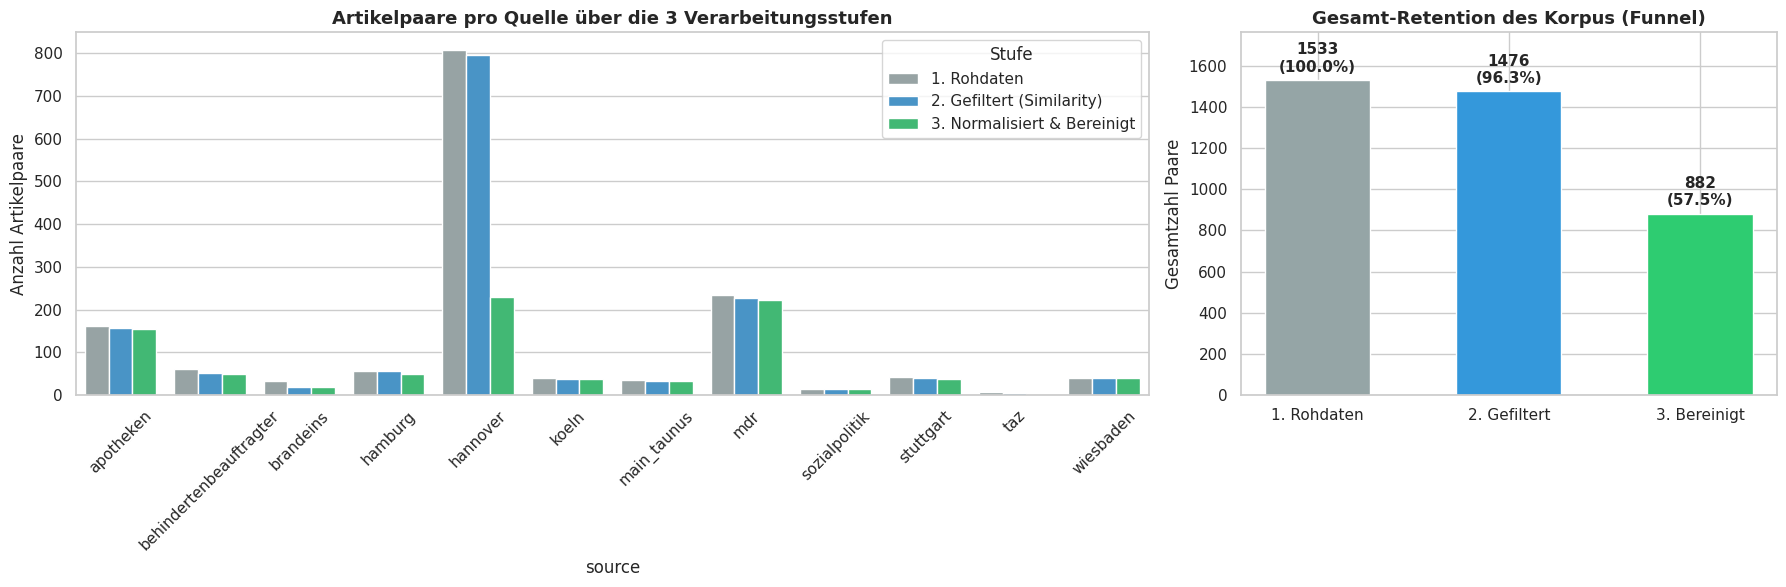

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1]})

# Plot 1: Barplot pro Quelle
plot_df = pivot_pairs[["1. Rohdaten", "2. Gefiltert (Similarity)", "3. Normalisiert & Bereinigt"]].reset_index()
plot_melted = pd.melt(plot_df, id_vars=["source"], var_name="Pipeline-Stufe", value_name="Anzahl Paare")

palette_stages = ["#95a5a6", "#3498db", "#2ecc71"]
sns.barplot(data=plot_melted, x="source", y="Anzahl Paare", hue="Pipeline-Stufe", palette=palette_stages, ax=axes[0])
axes[0].set_title("Artikelpaare pro Quelle über die 3 Verarbeitungsstufen", fontsize=13, fontweight="bold")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Anzahl Artikelpaare")
axes[0].legend(title="Stufe")

# Plot 2: Gesamter Pipeline-Funnel
funnel_data = pd.DataFrame({
    "Stufe": ["1. Rohdaten", "2. Gefiltert", "3. Bereinigt"],
    "Paare": [total_s1, total_s2, total_s3]
})
bars = axes[1].bar(funnel_data["Stufe"], funnel_data["Paare"], color=palette_stages, width=0.55)
axes[1].set_title("Gesamt-Retention des Korpus (Funnel)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Gesamtzahl Paare")
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 25, f"{int(yval)}\n({yval/total_s1*100:.1f}%)", ha='center', va='bottom', fontweight='bold')

axes[1].set_ylim(0, total_s1 * 1.15)
plt.tight_layout()
plt.show()


## 4. Text-, Wort- und LLM-Token-Volumen

Hier betrachten wir das aggregierte Volumen an Wörtern und LLM-Tokens (`tiktoken` cl100k_base) sowohl für die Zielsprache (Leichte Sprache, LS) als auch die Ausgangssprache (Alltagssprache, AS).

In [6]:
vol_summary = df_all.groupby(["stage_label"]).agg(
    Paare=("pair_id", "count"),
    LS_Tokens_Sum=("ls_tokens", "sum"),
    AS_Tokens_Sum=("as_tokens", "sum"),
    LS_Words_Sum=("ls_words", "sum"),
    AS_Words_Sum=("as_words", "sum"),
    LS_Tokens_Mean=("ls_tokens", "mean"),
    AS_Tokens_Mean=("as_tokens", "mean"),
    LS_Words_Mean=("ls_words", "mean"),
    AS_Words_Mean=("as_words", "mean")
).round(1)

vol_summary["LS/AS Token Ratio (Mittelwert)"] = (vol_summary["LS_Tokens_Sum"] / vol_summary["AS_Tokens_Sum"]).round(3)
display(vol_summary)


,Paare,LS_Tokens_Sum,AS_Tokens_Sum,LS_Words_Sum,AS_Words_Sum,LS_Tokens_Mean,AS_Tokens_Mean,LS_Words_Mean,AS_Words_Mean,LS/AS Token Ratio (Mittelwert)
stage_label,,,,,,,,,,
1. Rohdaten,1533,1468345,1868994,770795,863353,957.8,1219.2,502.8,563.2,0.786
2. Gefiltert (Similarity),1476,1433697,1793874,751901,829871,971.3,1215.4,509.4,562.2,0.799
3. Normalisiert & Bereinigt,882,703845,1085943,379831,504019,798.0,1231.2,430.6,571.5,0.648


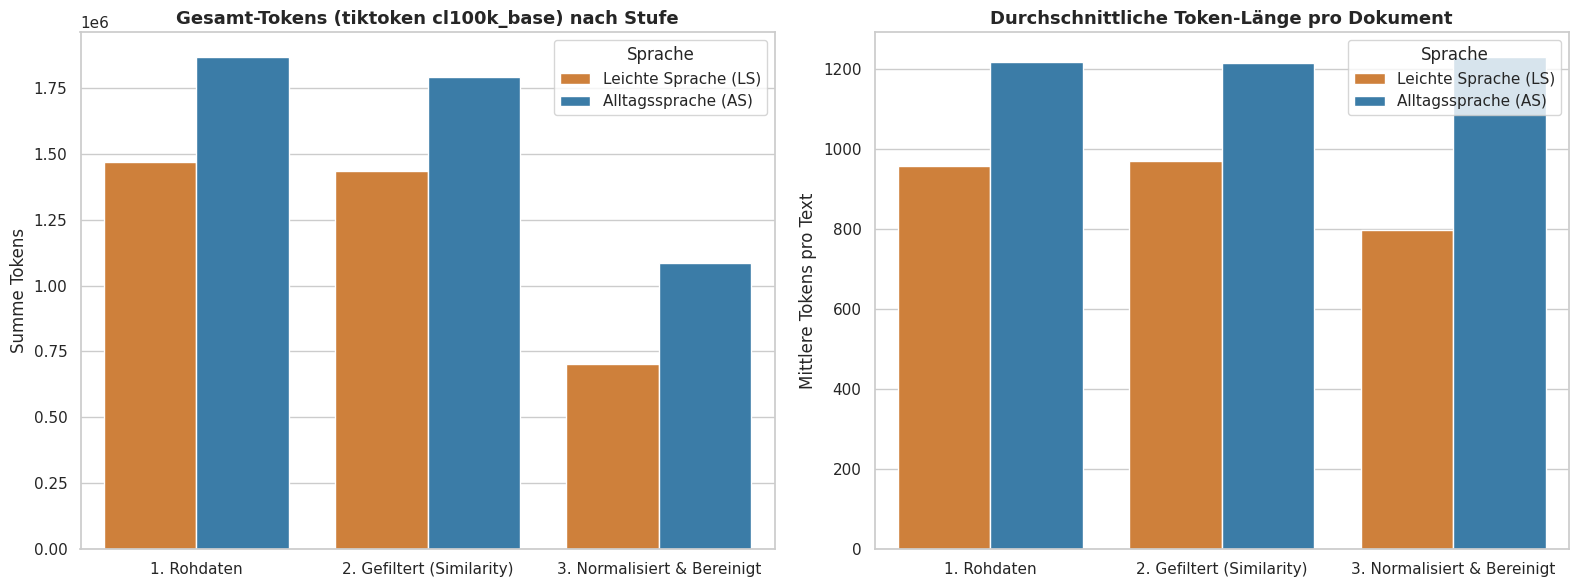

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Gesamt-Tokens (LS vs AS)
token_melt = df_all.groupby("stage_label")[["ls_tokens", "as_tokens"]].sum().reset_index()
token_melt = pd.melt(token_melt, id_vars=["stage_label"], value_vars=["ls_tokens", "as_tokens"], var_name="Sprache", value_name="Gesamt-Tokens")
token_melt["Sprache"] = token_melt["Sprache"].map({"ls_tokens": "Leichte Sprache (LS)", "as_tokens": "Alltagssprache (AS)"})

sns.barplot(data=token_melt, x="stage_label", y="Gesamt-Tokens", hue="Sprache", palette=["#e67e22", "#2980b9"], ax=axes[0])
axes[0].set_title("Gesamt-Tokens (tiktoken cl100k_base) nach Stufe", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Summe Tokens")
axes[0].set_xlabel("")

# Plot 2: Durchschnittliche Tokenlänge pro Dokument
token_mean_melt = df_all.groupby("stage_label")[["ls_tokens", "as_tokens"]].mean().reset_index()
token_mean_melt = pd.melt(token_mean_melt, id_vars=["stage_label"], value_vars=["ls_tokens", "as_tokens"], var_name="Sprache", value_name="Durchschnittliche Tokens")
token_mean_melt["Sprache"] = token_mean_melt["Sprache"].map({"ls_tokens": "Leichte Sprache (LS)", "as_tokens": "Alltagssprache (AS)"})

sns.barplot(data=token_mean_melt, x="stage_label", y="Durchschnittliche Tokens", hue="Sprache", palette=["#e67e22", "#2980b9"], ax=axes[1])
axes[1].set_title("Durchschnittliche Token-Länge pro Dokument", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Mittlere Tokens pro Text")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


## 5. Längenverhältnisse ($LS / AS$) & Ausreißer-Eliminierung

Ein zentraler Schritt in `normalize_clean.py` ist die Durchsetzung eines konsistenten Längenverhältnisses ($0.20 \le \text{Ratio} \le 4.00$) und Mindestwortzahl ($\ge 30$ Wörter).
Dadurch werden fehlerhafte Paarungen (z.B. vollständige Broschüre gepaart mit 1-Satz-Übersichts-Teaser) zuverlässig eliminiert.

Statistiken des Wortlängen-Verhältnisses (LS / AS):


,Min,P25,Median,Mean,P75,Max,Std
stage_label,,,,,,,
1. Rohdaten,0.013,0.638,1.043,1.416,1.605,28.080,1.741
2. Gefiltert (Similarity),0.070,0.644,1.054,1.385,1.605,16.500,1.524
3. Normalisiert & Bereinigt,0.188,0.526,0.839,0.984,1.311,3.899,0.607


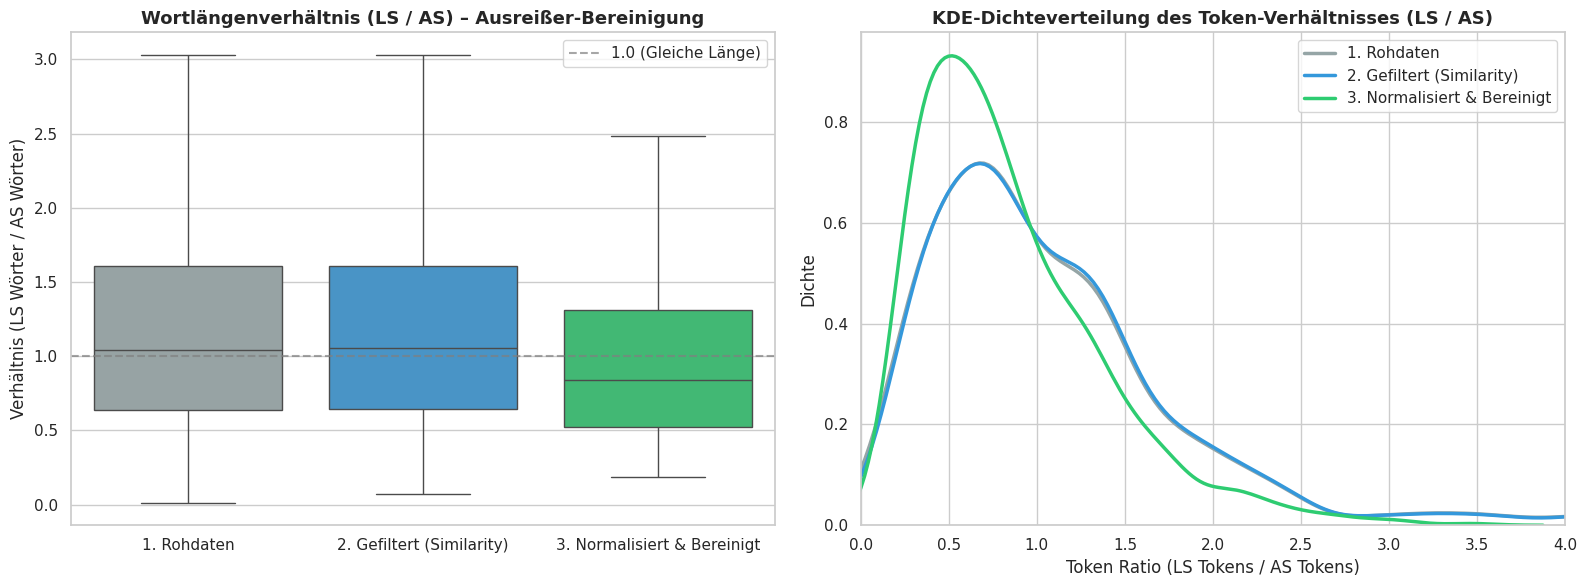

In [8]:
# Statistische Kennzahlen des Längenverhältnisses (LS Wörter / AS Wörter)
ratio_stats = df_all.groupby("stage_label")["word_ratio"].agg(
    Min="min",
    P25=lambda x: x.quantile(0.25),
    Median="median",
    Mean="mean",
    P75=lambda x: x.quantile(0.75),
    Max="max",
    Std="std"
).round(3)

print("Statistiken des Wortlängen-Verhältnisses (LS / AS):")
display(ratio_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Boxplot Längenverhältnis
sns.boxplot(data=df_all, x="stage_label", y="word_ratio", hue="stage_label", palette=palette_stages, legend=False, showfliers=False, ax=axes[0])
axes[0].set_title("Wortlängenverhältnis (LS / AS) – Ausreißer-Bereinigung", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Verhältnis (LS Wörter / AS Wörter)")
axes[0].set_xlabel("")
axes[0].axhline(1.0, color="gray", linestyle="--", alpha=0.7, label="1.0 (Gleiche Länge)")
axes[0].legend()

# Plot 2: KDE Verteilung der Token-Ratio
for stage_name, color in zip(["1. Rohdaten", "2. Gefiltert (Similarity)", "3. Normalisiert & Bereinigt"], palette_stages):
    subset = df_all[(df_all["stage_label"] == stage_name) & (df_all["token_ratio"] < 4.5)]
    sns.kdeplot(subset["token_ratio"], label=stage_name, color=color, linewidth=2.5, ax=axes[1])

axes[1].set_title("KDE-Dichteverteilung des Token-Verhältnisses (LS / AS)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Token Ratio (LS Tokens / AS Tokens)")
axes[1].set_ylabel("Dichte")
axes[1].set_xlim(0, 4.0)
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Boilerplate-Bias & Floskel-Prävalenz (Vorher vs. Nachher)

Wir analysieren nun die Durchdringung des Korpus mit Web-Boilerplate über die 5 definierten Kategorien sowie die Mediopunkt-Normalisierung.

Boilerplate-Prävalenz je Pipeline-Stufe (% der Artikel):


stage_label,1. Rohdaten,2. Gefiltert (Similarity),3. Normalisiert & Bereinigt
1. Navigation & Links,63.34,64.23,27.78
2. Frageketten & Tools,52.77,53.79,29.59
3. Disclaimer & Warnungen,43.18,43.70,18.82
4. Credits & Prüfstellen,14.02,13.96,0.68
5. Regionale & Bild-Artefakte,0.72,0.75,0.45
>>> GESAMT: Beliebiges Boilerplate (%),69.99,70.87,48.87
>>> Mediopunkte vorhanden (%),51.08,51.96,0.00


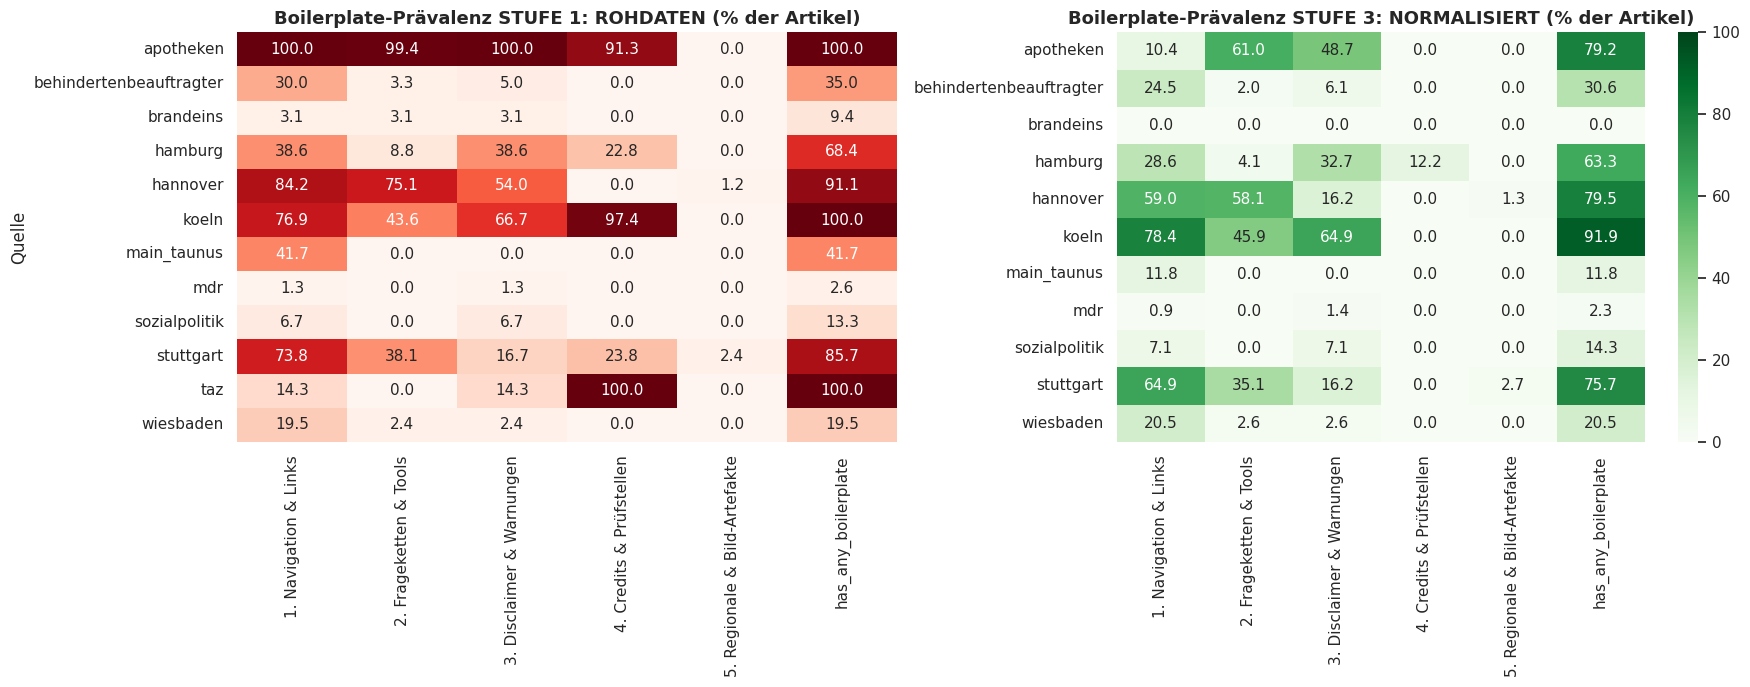

In [9]:
# Boilerplate-Prävalenz pro Stufe (in % aller Artikel)
cats = list(boilerplate_categories.keys()) + ["has_any_boilerplate", "has_mediopunkt"]

bp_stage_summary = (df_all.groupby("stage_label")[cats].mean() * 100).round(2)
bp_stage_summary.rename(columns={
    "has_any_boilerplate": ">>> GESAMT: Beliebiges Boilerplate (%)",
    "has_mediopunkt": ">>> Mediopunkte vorhanden (%)"
}, inplace=True)

print("Boilerplate-Prävalenz je Pipeline-Stufe (% der Artikel):")
display(bp_stage_summary.T)

# Heatmap-Vergleich pro Quelle: Rohdaten (Stufe 1) vs Bereinigt (Stufe 3)
raw_df = df_all[df_all["stage_key"] == "1_raw"]
clean_df = df_all[df_all["stage_key"] == "3_normalized"]

heat_cols = list(boilerplate_categories.keys()) + ["has_any_boilerplate"]

heat_raw = raw_df.groupby("source")[heat_cols].mean() * 100
heat_clean = clean_df.groupby("source")[heat_cols].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(heat_raw, annot=True, fmt=".1f", cmap="Reds", cbar=False, ax=axes[0], vmin=0, vmax=100)
axes[0].set_title("Boilerplate-Prävalenz STUFE 1: ROHDATEN (% der Artikel)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Quelle")

sns.heatmap(heat_clean, annot=True, fmt=".1f", cmap="Greens", cbar=True, ax=axes[1], vmin=0, vmax=100)
axes[1].set_title("Boilerplate-Prävalenz STUFE 3: NORMALISIERT (% der Artikel)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 7. Satzlängen ($W/S$) & Lexikalische Komplexität (LS vs. AS)

In der Leichten Sprache gilt die Regel: **Ein Satz = eine Information (kurze Sätze)**.
Wir prüfen, wie sich die durchschnittliche Satzlänge (Wörter pro Satz, $W/S$) zwischen LS und AS unterscheidet und wie stabil diese Metrik über die Filterstufen bleibt.

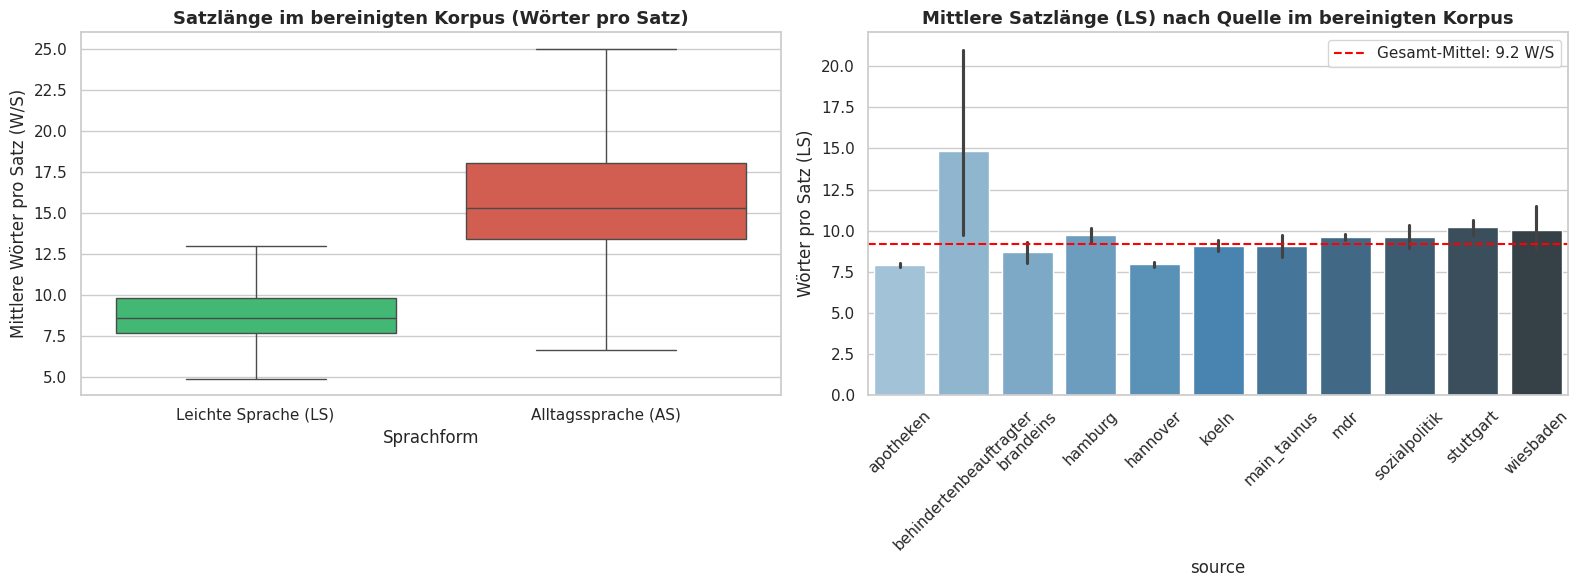

Durchschnittliche Satzlänge Leichte Sprache (LS):  9.17 Wörter/Satz (Median: 8.58)
Durchschnittliche Satzlänge Alltagssprache (AS):  16.76 Wörter/Satz (Median: 15.31)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Satzlänge LS vs AS im bereinigten Korpus
clean_subset = df_all[df_all["stage_key"] == "3_normalized"]
sents_df = pd.DataFrame({
    "Wörter pro Satz": list(clean_subset["ls_w_per_s"]) + list(clean_subset["as_w_per_s"]),
    "Sprachform": ["Leichte Sprache (LS)"] * len(clean_subset) + ["Alltagssprache (AS)"] * len(clean_subset)
})

sns.boxplot(data=sents_df, x="Sprachform", y="Wörter pro Satz", hue="Sprachform", palette=["#2ecc71", "#e74c3c"], legend=False, showfliers=False, ax=axes[0])
axes[0].set_title("Satzlänge im bereinigten Korpus (Wörter pro Satz)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Mittlere Wörter pro Satz (W/S)")

# Plot 2: Satzlänge pro Quelle in Leichter Sprache
sns.barplot(data=clean_subset, x="source", y="ls_w_per_s", hue="source", palette="Blues_d", legend=False, ax=axes[1])
axes[1].set_title("Mittlere Satzlänge (LS) nach Quelle im bereinigten Korpus", fontsize=13, fontweight="bold")
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel("Wörter pro Satz (LS)")
axes[1].axhline(clean_subset["ls_w_per_s"].mean(), color="red", linestyle="--", label=f"Gesamt-Mittel: {clean_subset['ls_w_per_s'].mean():.1f} W/S")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Durchschnittliche Satzlänge Leichte Sprache (LS):  {clean_subset['ls_w_per_s'].mean():.2f} Wörter/Satz (Median: {clean_subset['ls_w_per_s'].median():.2f})")
print(f"Durchschnittliche Satzlänge Alltagssprache (AS):  {clean_subset['as_w_per_s'].mean():.2f} Wörter/Satz (Median: {clean_subset['as_w_per_s'].median():.2f})")


## 8. Qualitative Fallstudien: Konkrete Text-Deltas vor vs. nach Bereinigung

Hier untersuchen wir konkrete Beispiele aus den wichtigsten Quellen (**Apotheken**, **Hannover**, **Stuttgart**, **MDR**), um die exakten Bereinigungs-Deltas transparent zu demonstrieren.

In [11]:
sample_sources = ["apotheken", "hannover", "stuttgart", "mdr"]

for src in sample_sources:
    raw_match = df_all[(df_all["stage_key"] == "1_raw") & (df_all["source"] == src)]
    clean_match = df_all[(df_all["stage_key"] == "3_normalized") & (df_all["source"] == src)]
    
    if not raw_match.empty and not clean_match.empty:
        r_text = raw_match.iloc[0]["ls_text"]
        c_text = clean_match.iloc[0]["ls_text"]
        
        print("=" * 90)
        print(f"QUELLE: {src.upper()}")
        print("=" * 90)
        print(f"[STUFE 1 - ROHDATEN] (Länge: {len(r_text)} Zeichen, {len(r_text.split())} Wörter):")
        # Letzte 300 Zeichen anzeigen, wo typischerweise das Boilerplate saß
        tail_raw = r_text[-350:] if len(r_text) > 350 else r_text
        print(f"... {tail_raw.strip()}")
        print("\n" + "-" * 45 + "\n")
        print(f"[STUFE 3 - BEREINIGT] (Länge: {len(c_text)} Zeichen, {len(c_text.split())} Wörter):")
        tail_clean = c_text[-350:] if len(c_text) > 350 else c_text
        print(f"... {tail_clean.strip()}")
        print("\n")


QUELLE: APOTHEKEN
[STUFE 1 - ROHDATEN] (Länge: 5116 Zeichen, 752 Wörter):
... sprechen. Rufen Sie in der Arztpraxis an. Die Texte haben wir zusammen mit der Forschungsstelle Leichte Sprache geschrieben. Die Forschungsstelle Leichte Sprache ist an der Universität Hildesheim. Welche Frage zu Augen haben Sie? Unser Tool durchsucht unsere Artikel um Ihre Frage bestmöglich zu beantworten. Ihre Frage wird nicht gespeichert. Augen

---------------------------------------------

[STUFE 3 - BEREINIGT] (Länge: 4424 Zeichen, 655 Wörter):
... cht eine künstliche Linse einsetzen. Dann kann Ihr Augenarzt Sie zu möglichen Behandlungen beraten. Die Texte ersetzen die Beratung durch den Arzt nicht. Nur ein Arzt kann Ihnen genaue Informationen geben. Sie fühlen sich krank? Oder Sie haben Fragen zu einer Krankheit? Dann sollten Sie immer mit Ihrem Arzt sprechen. Rufen Sie in der Arztpraxis an.


QUELLE: HANNOVER
[STUFE 1 - ROHDATEN] (Länge: 4510 Zeichen, 716 Wörter):
... ersuchungen.
Auch Schüler in den 